# freqk vs vg giraffe — true vs estimated AF

Side-by-side performance comparison of freqk (k-mer based, fast) and vg giraffe (graph alignment + `vg pack` + `vg call`) at estimating pool allele frequency.

Both methods are run on the same simulated reads. We scan all matched (rep, coverage, size, freq) combinations on disk, then partition the comparison by:

1. **Coverage** (10×, 20×, 50×) — does graph alignment help most when coverage is thin?
2. **SV size** (100bp → 10kb) — does either method break on small/large deletions?
3. **True frequency** (0.10 → 0.90) — accuracy across the AF range
4. **Detection rate** — fraction of (combo) where each method returns a non-NA estimate

Only k=31 reps 1–10 (the matched benchmark set) are used.

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

WORK     = '..'
PLOT_DIR = os.path.join(WORK, 'plots')
os.makedirs(PLOT_DIR, exist_ok=True)

SIZE_ORDER  = ['100bp', '500bp', '1kb', '5kb', '10kb']
FREQ_ORDER  = [0.10, 0.30, 0.50, 0.70, 0.90]
COV_ORDER   = [10, 20, 50]
METHODS     = ['freqk', 'vg_giraffe']
METHOD_COLOR = {'freqk': '#1f77b4', 'vg_giraffe': '#d62728'}
SIZE_COLORS  = dict(zip(SIZE_ORDER, sns.color_palette('viridis', len(SIZE_ORDER))))

## Scan AF TSVs into a long DataFrame

freqk and vg outputs share the same flat layout — single line `af_ref|af_alt` (or `NA|NA`). We tag each row with a `method` column and filter to k=31, rep1–rep10.

In [2]:
PATTERN = os.path.join(
    WORK,
    'results/del/rep*/var/cov*_err001/*/n231/f*/k31/'
    'var_del_*.allele_frequencies.k31.tsv',
)
RX = re.compile(
    r'results/del/(?P<rep>rep\d+)/var/cov(?P<cov>\d+)_err001/'
    r'(?P<size>[^/]+)/n(?P<n>\d+)/f(?P<f>\d+)/k(?P<k>\d+)/'
    r'var_del_[^/]+_n\d+_f\d+_err\d+'
    r'(?:\.(?P<vg>vg_giraffe))?\.allele_frequencies\.k\d+\.tsv$'
)

BENCH_REPS = {f'rep{i}' for i in range(1, 11)}

rows = []
for fp in glob.glob(PATTERN):
    m = RX.search(fp)
    if not m:
        continue
    if m['rep'] not in BENCH_REPS:
        continue

    method = 'vg_giraffe' if m['vg'] else 'freqk'
    try:
        line = open(fp).read().strip()
        if line:
            a, b = line.split('|')
            af_ref = float('nan') if a == 'NA' else float(a)
            af_alt = float('nan') if b == 'NA' else float(b)
        else:
            af_ref = af_alt = float('nan')
    except Exception:
        af_ref = af_alt = float('nan')

    rows.append({
        'rep'         : m['rep'],
        'coverage'    : int(m['cov']),
        'size'        : m['size'],
        'freq_label'  : int(m['f']),
        'freq_nominal': int(m['f']) / 100.0,
        'method'      : method,
        'af_ref'      : af_ref,
        'af_alt'      : af_alt,
    })

df = pd.DataFrame(rows)
df['detected']       = df['af_alt'].notna()
df['af_alt_imputed'] = df['af_alt'].fillna(0.0)

print(f'{len(df):,} rows, {df["rep"].nunique()} reps, {sorted(df["coverage"].unique())} cov')
print()
print('Counts by method × coverage:')
print(df.groupby(['method', 'coverage']).size().unstack(fill_value=0))

1,429 rows, 10 reps, [10, 20, 50] cov

Counts by method × coverage:
coverage     10   20   50
method                   
freqk       250  250  250
vg_giraffe  250  250  179


In [3]:
# Filter at the (rep, coverage) level: only include a (rep, cov) cell when
# BOTH methods have the full 5 sizes x 5 freqs = 25-combo grid. Drops reps
# whose vg-giraffe runs are still in flight, so freqk and vg are scored on
# the same trial set instead of freqk getting credit for combos vg never ran.
FULL_GRID = len(SIZE_ORDER) * len(FREQ_ORDER)  # 25

grid_count = (df.groupby(['rep', 'coverage', 'method']).size()
                .unstack('method', fill_value=0))
complete = grid_count[(grid_count[METHODS] == FULL_GRID).all(axis=1)].index  # MultiIndex (rep, cov)

matched = df[df.set_index(['rep', 'coverage']).index.isin(complete)].copy()

print(f'Complete (rep, coverage) cells: {len(complete)}')
print(f'Matched rows: {len(matched):,}  ({len(matched)//2:,} combos x 2 methods)')
print()
print('Reps included per coverage:')
for cov in COV_ORDER:
    reps_in   = sorted({r for r, c in complete if c == cov},
                       key=lambda r: int(r[3:]))
    reps_out  = sorted({r for r in BENCH_REPS if r not in reps_in},
                       key=lambda r: int(r[3:]))
    print(f'  cov={cov:>2}x  in:  {reps_in}')
    if reps_out:
        print(f'           out: {reps_out}  (incomplete vg grid)')
print()
print('Matched rows by coverage:')
print(matched.groupby(['method', 'coverage']).size().unstack(fill_value=0))


Complete (rep, coverage) cells: 25
Matched rows: 1,250  (625 combos x 2 methods)

Reps included per coverage:
  cov=10x  in:  ['rep1', 'rep2', 'rep3', 'rep4', 'rep5', 'rep6', 'rep7', 'rep8', 'rep9', 'rep10']
  cov=20x  in:  ['rep1', 'rep2', 'rep3', 'rep4', 'rep5', 'rep6', 'rep7', 'rep8', 'rep9', 'rep10']
  cov=50x  in:  ['rep1', 'rep2', 'rep3', 'rep4', 'rep10']
           out: ['rep5', 'rep6', 'rep7', 'rep8', 'rep9']  (incomplete vg grid)

Matched rows by coverage:
coverage     10   20   50
method                   
freqk       250  250  125
vg_giraffe  250  250  125


## R² + RMSE helpers

We report two flavors for each panel:

- **R² (detected only)** — Pearson R² over rows where the method returned a non-NA AF. Tells you how good the estimate is *when it works*.
- **R² (imputed)** — non-detected combos imputed as AF=0 (what a downstream pipeline would see). Penalizes high miss rates and is the more honest end-to-end number.

In [4]:
def r2_pearson(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) < 2 or np.var(y_true) == 0 or np.var(y_pred) == 0:
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1] ** 2)

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if len(y_true) == 0:
        return np.nan
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def panel_metrics(g):
    det = g.dropna(subset=['af_alt'])
    return pd.Series({
        'n_total'       : len(g),
        'n_detected'    : len(det),
        'detection_rate': det.shape[0] / len(g) if len(g) else np.nan,
        'r2_det'        : r2_pearson(det['freq_nominal'], det['af_alt']),
        'rmse_det'      : rmse     (det['freq_nominal'], det['af_alt']),
        'r2_imp'        : r2_pearson(g['freq_nominal'], g['af_alt_imputed']),
        'rmse_imp'      : rmse     (g['freq_nominal'], g['af_alt_imputed']),
    })

## Plot 1 — pooled true vs estimated AF, freqk vs vg side-by-side

All matched combos pooled. Quickest read on whether either method has a systematic bias.

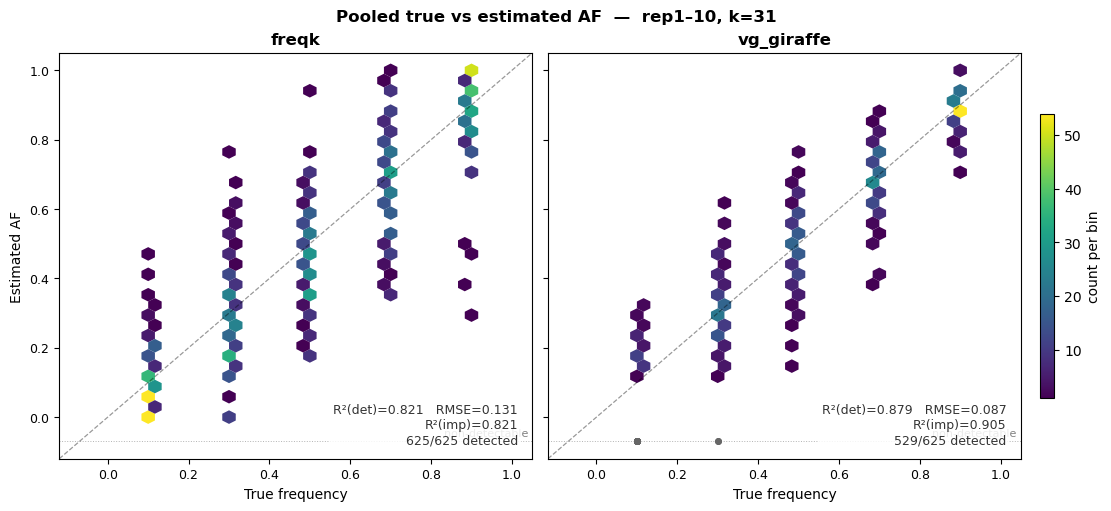

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5),
                         sharex=True, sharey=True, constrained_layout=True)
lo, hi, ND_Y = -0.12, 1.05, -0.07

for ax, mth in zip(axes, METHODS):
    sub  = matched[matched['method'] == mth]
    det  = sub.dropna(subset=['af_alt'])
    ndet = sub[~sub['detected']]

    hb = ax.hexbin(det['freq_nominal'], det['af_alt'],
                   gridsize=30, extent=(0, 1, 0, 1),
                   cmap='viridis', mincnt=1, linewidths=0, zorder=2)
    if not ndet.empty:
        ax.scatter(ndet['freq_nominal'], [ND_Y] * len(ndet),
                   color='0.4', s=14, alpha=0.5, zorder=3)

    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.9, alpha=0.4, zorder=4)
    ax.axhline(ND_Y, color='0.7', lw=0.7, ls=':')
    ax.text(hi - 0.01, ND_Y + 0.01, 'non-detectable',
            ha='right', va='bottom', fontsize=8, color='0.5')

    n_tot, n_det = len(sub), len(det)
    ax.text(0.97, 0.03,
            f'R²(det)={r2_pearson(det["freq_nominal"], det["af_alt"]):.3f}'
            f'   RMSE={rmse(det["freq_nominal"], det["af_alt"]):.3f}\n'
            f'R²(imp)={r2_pearson(sub["freq_nominal"], sub["af_alt_imputed"]):.3f}\n'
            f'{n_det}/{n_tot} detected',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=9, color='0.2',
            bbox=dict(fc='white', ec='none', alpha=0.85, pad=2))

    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(mth, fontsize=12, fontweight='bold')
    ax.set_xlabel('True frequency', fontsize=10)
    ax.tick_params(labelsize=9)

axes[0].set_ylabel('Estimated AF', fontsize=10)
fig.colorbar(hb, ax=axes, location='right', shrink=0.7, pad=0.02,
             label='count per bin')
fig.suptitle('Pooled true vs estimated AF  —  rep1–10, k=31',
             fontsize=12, fontweight='bold')

plt.savefig(f'{PLOT_DIR}/freqk_vs_vg_pooled.png', bbox_inches='tight', dpi=200)
plt.show()

## Plot 2 — partitioned by coverage

3 coverages × 2 methods. The vg-giraffe column should win at low coverage if graph alignment recovers reads that fragment k-mer counts in freqk.

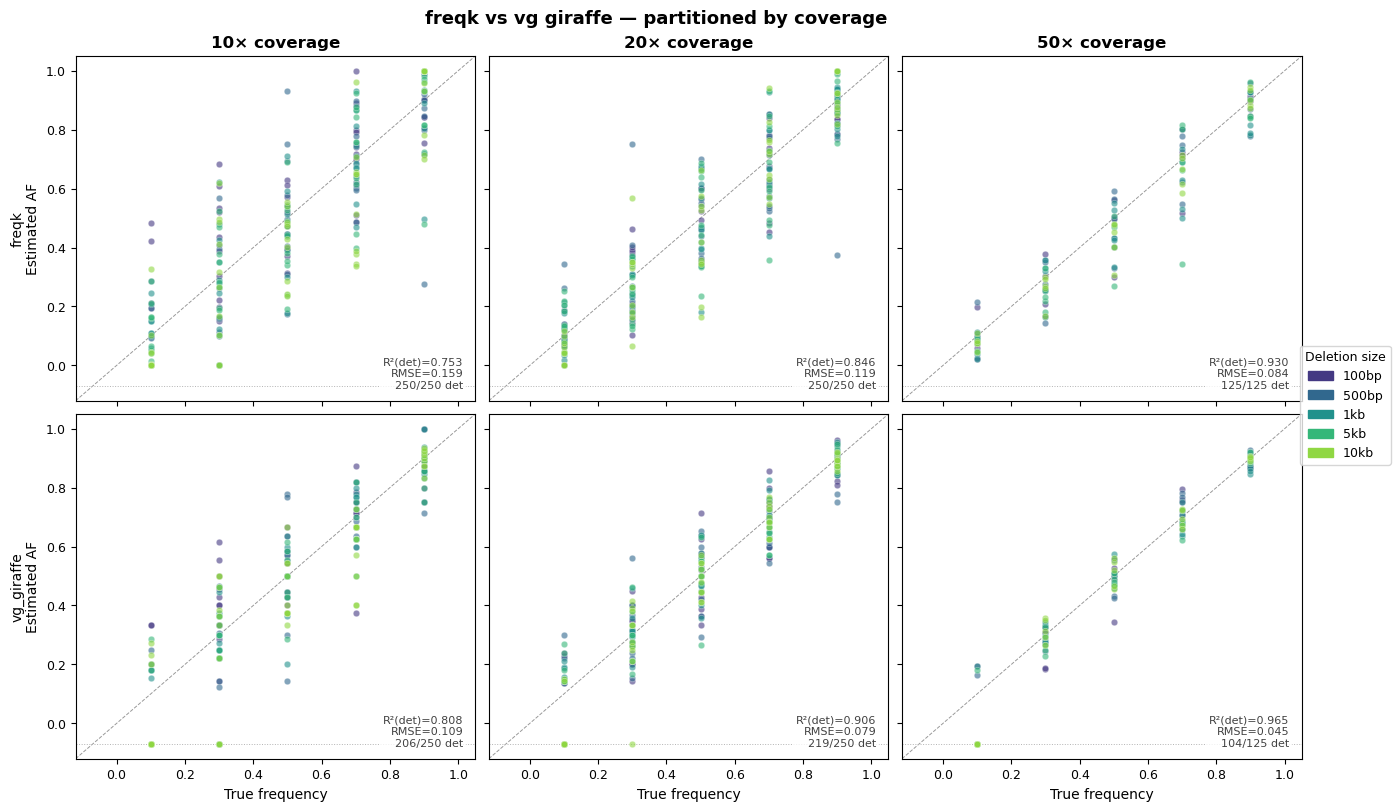

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8),
                         sharex=True, sharey=True, constrained_layout=True)
lo, hi, ND_Y = -0.12, 1.05, -0.07

for j, cov in enumerate(COV_ORDER):
    for i, mth in enumerate(METHODS):
        ax = axes[i, j]
        sub = matched[(matched['method'] == mth) & (matched['coverage'] == cov)]
        det = sub.dropna(subset=['af_alt'])
        ndet = sub[~sub['detected']]

        for s in SIZE_ORDER:
            pts = det[det['size'] == s]
            if not pts.empty:
                ax.scatter(pts['freq_nominal'], pts['af_alt'],
                           color=SIZE_COLORS[s], s=22, alpha=0.6,
                           edgecolors='white', linewidths=0.3, zorder=3)
            pts = ndet[ndet['size'] == s]
            if not pts.empty:
                ax.scatter(pts['freq_nominal'], [ND_Y] * len(pts),
                           color=SIZE_COLORS[s], s=22, alpha=0.6,
                           edgecolors='white', linewidths=0.3, zorder=3)

        ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7, alpha=0.4)
        ax.axhline(ND_Y, color='0.7', lw=0.7, ls=':')

        ax.text(0.97, 0.03,
                f'R²(det)={r2_pearson(det["freq_nominal"], det["af_alt"]):.3f}\n'
                f'RMSE={rmse(det["freq_nominal"], det["af_alt"]):.3f}\n'
                f'{len(det)}/{len(sub)} det',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8, color='0.25',
                bbox=dict(fc='white', ec='none', alpha=0.8, pad=2))

        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        if i == 0:
            ax.set_title(f'{cov}× coverage', fontsize=12, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f'{mth}\nEstimated AF', fontsize=10)
        if i == 1:
            ax.set_xlabel('True frequency', fontsize=10)
        ax.tick_params(labelsize=9)

size_patches = [mpatches.Patch(color=SIZE_COLORS[s], label=s) for s in SIZE_ORDER]
fig.legend(handles=size_patches, title='Deletion size',
           loc='center right', bbox_to_anchor=(1.07, 0.5),
           fontsize=9, title_fontsize=9, frameon=True)
fig.suptitle('freqk vs vg giraffe — partitioned by coverage',
             fontsize=13, fontweight='bold')

plt.savefig(f'{PLOT_DIR}/freqk_vs_vg_by_coverage.png',
            bbox_inches='tight', dpi=200)
plt.show()

## Plot 3 — partitioned by SV size

5 sizes × 2 methods. Tells us where each method breaks: small SVs (less unique flanking k-mers) for freqk, very-large SVs (graph complexity) for vg.

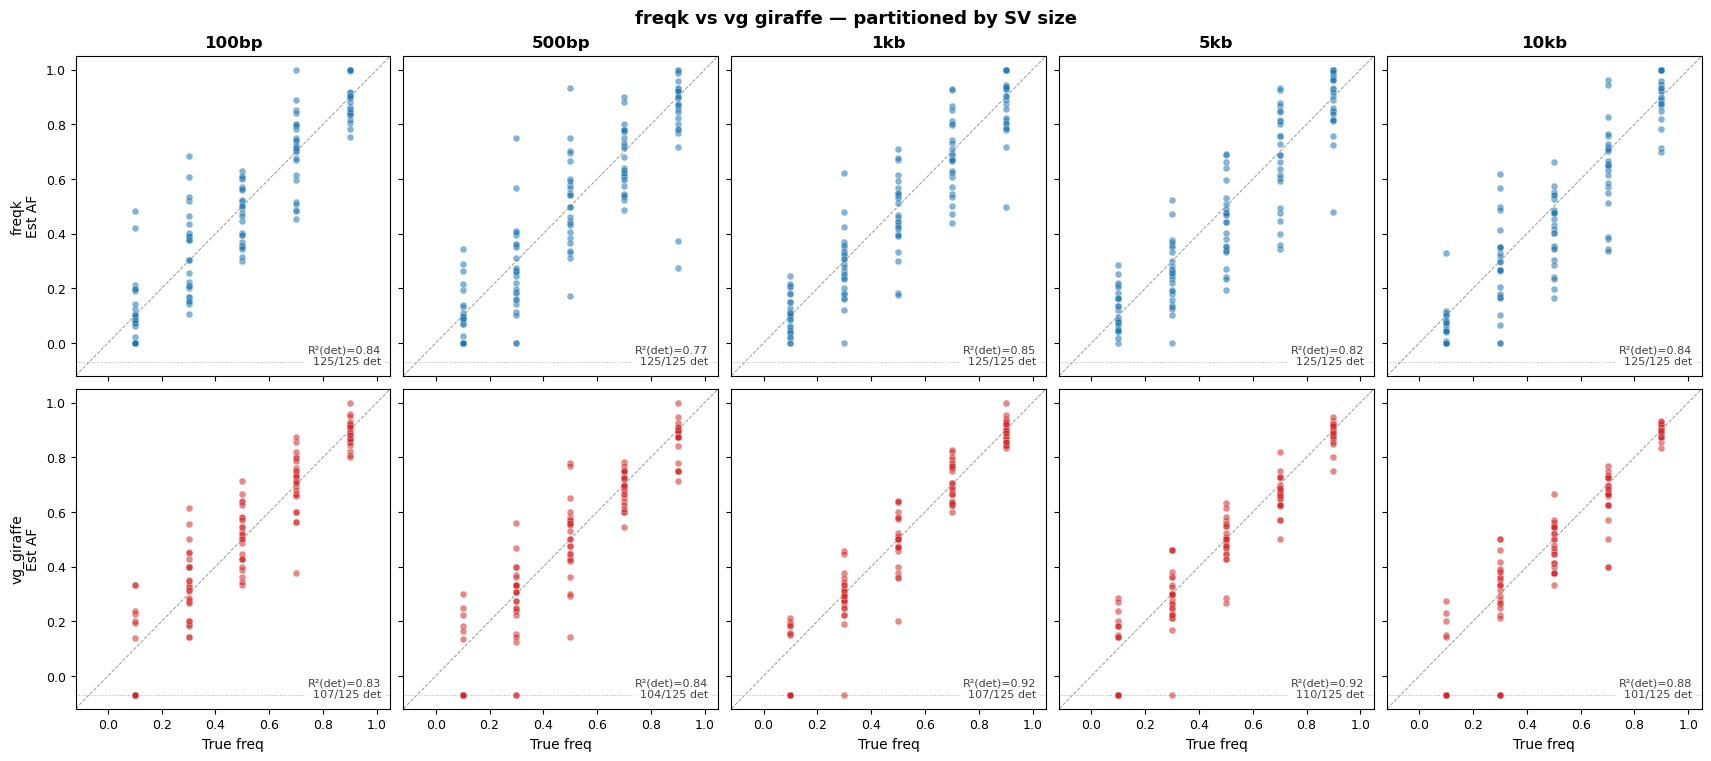

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(17, 7.5),
                         sharex=True, sharey=True, constrained_layout=True)
lo, hi, ND_Y = -0.12, 1.05, -0.07

for j, sz in enumerate(SIZE_ORDER):
    for i, mth in enumerate(METHODS):
        ax = axes[i, j]
        sub = matched[(matched['method'] == mth) & (matched['size'] == sz)]
        det = sub.dropna(subset=['af_alt'])
        ndet = sub[~sub['detected']]

        ax.scatter(det['freq_nominal'], det['af_alt'],
                   color=METHOD_COLOR[mth], s=24, alpha=0.55,
                   edgecolors='white', linewidths=0.3, zorder=3)
        if not ndet.empty:
            ax.scatter(ndet['freq_nominal'], [ND_Y] * len(ndet),
                       color=METHOD_COLOR[mth], s=24, alpha=0.55,
                       edgecolors='white', linewidths=0.3, zorder=3)

        ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7, alpha=0.4)
        ax.axhline(ND_Y, color='0.7', lw=0.7, ls=':')

        ax.text(0.97, 0.03,
                f'R²(det)={r2_pearson(det["freq_nominal"], det["af_alt"]):.2f}\n'
                f'{len(det)}/{len(sub)} det',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8, color='0.25',
                bbox=dict(fc='white', ec='none', alpha=0.8, pad=2))

        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        if i == 0:
            ax.set_title(sz, fontsize=12, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f'{mth}\nEst AF', fontsize=10)
        if i == 1:
            ax.set_xlabel('True freq', fontsize=10)
        ax.tick_params(labelsize=9)

fig.suptitle('freqk vs vg giraffe — partitioned by SV size',
             fontsize=13, fontweight='bold')
plt.savefig(f'{PLOT_DIR}/freqk_vs_vg_by_size.png',
            bbox_inches='tight', dpi=200)
plt.show()

## Plot 4 — R² × RMSE summary table by (method, coverage, size)

The numerical companion to plot 3. Lets us pick the (size × cov) regime where one method dominates.

In [8]:
summary = (matched
           .groupby(['method', 'coverage', 'size'])
           .apply(panel_metrics)
           .reset_index())
summary = summary.sort_values(
    ['method', 'coverage', 'size'],
    key=lambda c: c.map({s: i for i, s in enumerate(SIZE_ORDER)})
                  if c.name == 'size' else c,
)
summary[['method', 'coverage', 'size',
         'n_total', 'n_detected', 'detection_rate',
         'r2_det', 'rmse_det', 'r2_imp']]

,method,coverage,size,n_total,n_detected,detection_rate,r2_det,rmse_det,r2_imp
0,freqk,10,100bp,50.0,50.0,1.00,0.762956,0.152353,0.762956
3,freqk,10,500bp,50.0,50.0,1.00,0.725282,0.176892,0.725282
2,freqk,10,1kb,50.0,50.0,1.00,0.791651,0.141285,0.791651
4,freqk,10,5kb,50.0,50.0,1.00,0.770434,0.151785,0.770434
1,freqk,10,10kb,50.0,50.0,1.00,0.751371,0.170844,0.751371
5,freqk,20,100bp,50.0,50.0,1.00,0.882952,0.102361,0.882952
8,freqk,20,500bp,50.0,50.0,1.00,0.774874,0.137827,0.774874
7,freqk,20,1kb,50.0,50.0,1.00,0.875796,0.104934,0.875796
9,freqk,20,5kb,50.0,50.0,1.00,0.828023,0.126943,0.828023
6,freqk,20,10kb,50.0,50.0,1.00,0.879015,0.118647,0.879015


## Plot 5 — R² heatmaps per method (size × coverage)

Two heatmaps with a shared scale so you can read off where each method is strong. The third panel shows `vg − freqk` so positive cells mean vg wins.

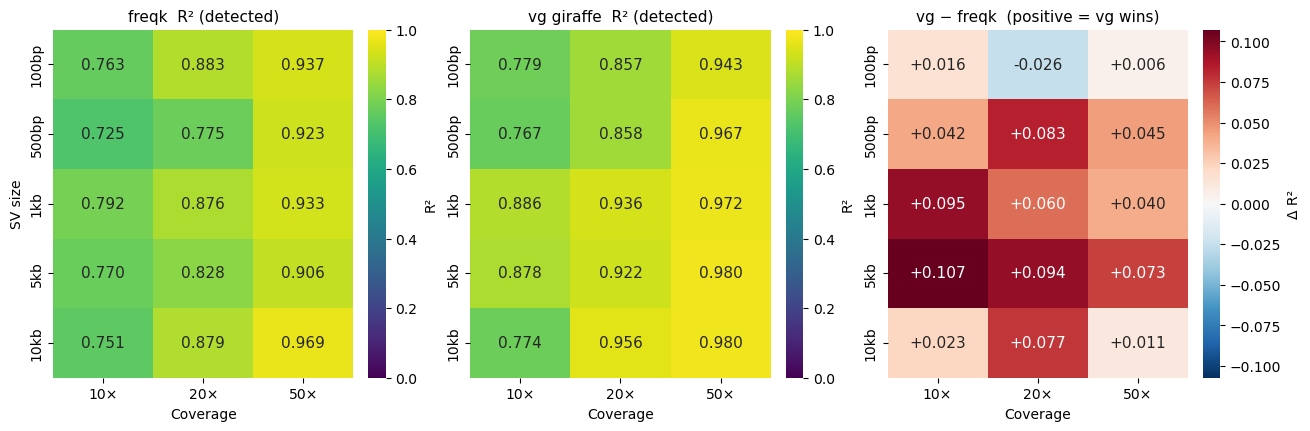

In [9]:
def pivot_r2(metric):
    out = {}
    for mth in METHODS:
        sub = summary[summary['method'] == mth]
        m = (sub.pivot(index='size', columns='coverage', values=metric)
                .reindex(index=SIZE_ORDER, columns=COV_ORDER))
        out[mth] = m
    return out

r2_det = pivot_r2('r2_det')
diff   = (r2_det['vg_giraffe'] - r2_det['freqk'])

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)

sns.heatmap(r2_det['freqk'], annot=True, fmt='.3f', vmin=0, vmax=1,
            cmap='viridis', ax=axes[0],
            xticklabels=[f'{c}×' for c in COV_ORDER], yticklabels=SIZE_ORDER,
            cbar_kws={'label': 'R²'},
            annot_kws={'fontsize': 11})
axes[0].set_title('freqk  R² (detected)', fontsize=11)
axes[0].set_xlabel('Coverage'); axes[0].set_ylabel('SV size')

sns.heatmap(r2_det['vg_giraffe'], annot=True, fmt='.3f', vmin=0, vmax=1,
            cmap='viridis', ax=axes[1],
            xticklabels=[f'{c}×' for c in COV_ORDER], yticklabels=SIZE_ORDER,
            cbar_kws={'label': 'R²'},
            annot_kws={'fontsize': 11})
axes[1].set_title('vg giraffe  R² (detected)', fontsize=11)
axes[1].set_xlabel('Coverage'); axes[1].set_ylabel('')

vmax_diff = max(0.05, np.nanmax(np.abs(diff.values)))
sns.heatmap(diff, annot=True, fmt='+.3f',
            cmap='RdBu_r', center=0, vmin=-vmax_diff, vmax=vmax_diff,
            ax=axes[2],
            xticklabels=[f'{c}×' for c in COV_ORDER], yticklabels=SIZE_ORDER,
            cbar_kws={'label': 'Δ R²'},
            annot_kws={'fontsize': 11})
axes[2].set_title('vg − freqk  (positive = vg wins)', fontsize=11)
axes[2].set_xlabel('Coverage'); axes[2].set_ylabel('')

plt.savefig(f'{PLOT_DIR}/freqk_vs_vg_r2_heatmap.png',
            bbox_inches='tight', dpi=200)
plt.show()

## Plot 6 — detection rate comparison

Fraction of (combo) where each method returns a non-NA AF, broken out by coverage × size. The big practical question: **how often does either method silently drop the variant?**

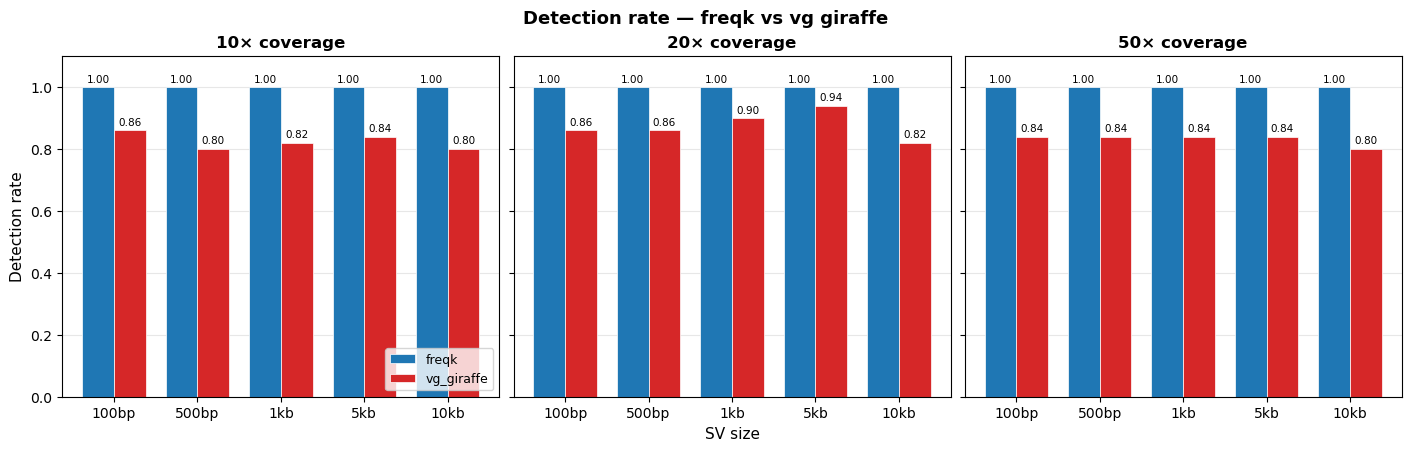

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4),
                         sharey=True, constrained_layout=True)

x     = np.arange(len(SIZE_ORDER))
width = 0.38

for ax, cov in zip(axes, COV_ORDER):
    for i, mth in enumerate(METHODS):
        rates = []
        for sz in SIZE_ORDER:
            sub = matched[(matched['method'] == mth) &
                          (matched['coverage'] == cov) &
                          (matched['size'] == sz)]
            rates.append(sub['detected'].mean() if len(sub) else np.nan)
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, rates, width,
                      color=METHOD_COLOR[mth], label=mth,
                      edgecolor='white', linewidth=0.5)
        for b, r in zip(bars, rates):
            if not np.isnan(r):
                ax.text(b.get_x() + b.get_width() / 2, r + 0.01,
                        f'{r:.2f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(SIZE_ORDER, fontsize=10)
    ax.set_title(f'{cov}× coverage', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

axes[0].set_ylabel('Detection rate', fontsize=11)
axes[1].set_xlabel('SV size', fontsize=11)
axes[0].legend(fontsize=9, loc='lower right')
fig.suptitle('Detection rate — freqk vs vg giraffe',
             fontsize=13, fontweight='bold')

plt.savefig(f'{PLOT_DIR}/freqk_vs_vg_detection_rate.png',
            bbox_inches='tight', dpi=200)
plt.show()

## Plot 7 — paired error scatter (vg vs freqk on the same combo)

For every (rep, cov, size, freq) combo, plot freqk's absolute error on x and vg's absolute error on y. Points above the diagonal: vg is worse on this combo. Below: vg wins. Coloured by coverage.

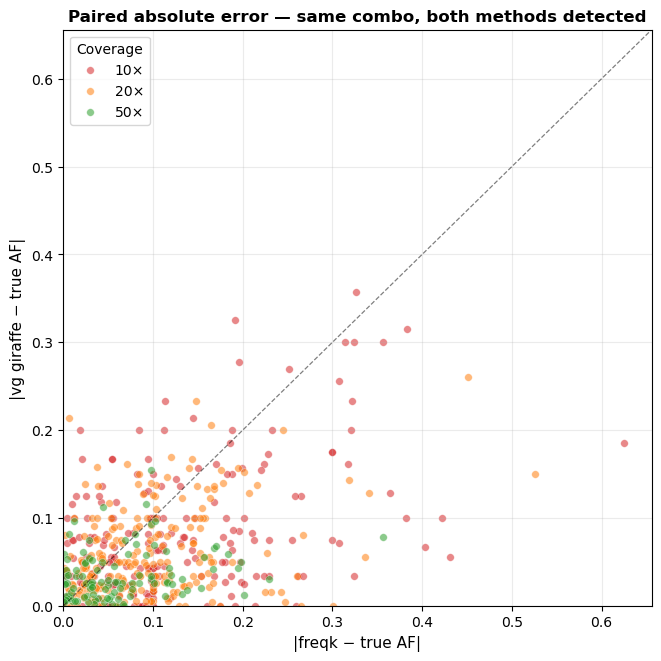

vg better :   357 / 529
freqk     :   171 / 529
tie       :     1


In [11]:
wide = (matched
        .pivot_table(index=['rep', 'coverage', 'size', 'freq_label', 'freq_nominal'],
                     columns='method', values='af_alt')
        .reset_index())
wide['err_freqk'] = (wide['freqk']      - wide['freq_nominal']).abs()
wide['err_vg']    = (wide['vg_giraffe'] - wide['freq_nominal']).abs()
wide_det = wide.dropna(subset=['err_freqk', 'err_vg'])

COV_COLORS = {10: '#d62728', 20: '#ff7f0e', 50: '#2ca02c'}

fig, ax = plt.subplots(figsize=(6.5, 6.5), constrained_layout=True)
for cov in COV_ORDER:
    s = wide_det[wide_det['coverage'] == cov]
    ax.scatter(s['err_freqk'], s['err_vg'],
               color=COV_COLORS[cov], s=30, alpha=0.55,
               edgecolors='white', linewidths=0.4, label=f'{cov}×')

lim = max(wide_det['err_freqk'].max(), wide_det['err_vg'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.9, alpha=0.5)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('|freqk − true AF|', fontsize=11)
ax.set_ylabel('|vg giraffe − true AF|', fontsize=11)
ax.set_title('Paired absolute error — same combo, both methods detected',
             fontsize=12, fontweight='bold')
ax.legend(title='Coverage', loc='upper left', frameon=True)
ax.grid(alpha=0.25)

plt.savefig(f'{PLOT_DIR}/freqk_vs_vg_paired_error.png',
            bbox_inches='tight', dpi=200)
plt.show()

n_vg_better    = int((wide_det['err_vg'] < wide_det['err_freqk']).sum())
n_freqk_better = int((wide_det['err_freqk'] < wide_det['err_vg']).sum())
n_tie          = int((wide_det['err_freqk'] == wide_det['err_vg']).sum())
print(f'vg better : {n_vg_better:>5} / {len(wide_det)}')
print(f'freqk     : {n_freqk_better:>5} / {len(wide_det)}')
print(f'tie       : {n_tie:>5}')

## Runtime — per-step elapsed seconds

Each pipeline step writes a `*.runtimes.k31.tsv` next to the AF TSV with columns
`method | size | step | elapsed_s | cached`.

- **vg giraffe** steps: `autoindex`, `giraffe`, `pack`, `call`
- **freqk** steps: `index`, `combine_reads`, `var-dedup`, `ref-dedup`, `count`, `call`

`cached=1` rows mean the step was skipped because its output existed (index re-use).
We drop those when reporting per-step distributions so a re-used `autoindex` doesn't pull the mean down to 0.

Runtime instrumentation was added mid-pipeline so older combos have no timing TSV — this section uses whatever's on disk and reports the count.


In [12]:
RT_PATTERN = os.path.join(
    WORK,
    'results/del/rep*/var/cov*_err001/*/n231/f*/k31/'
    'var_del_*.runtimes.k31.tsv',
)
RT_RX = re.compile(
    r'results/del/(?P<rep>rep\d+)/var/cov(?P<cov>\d+)_err001/'
    r'(?P<size>[^/]+)/n(?P<n>\d+)/f(?P<f>\d+)/k(?P<k>\d+)/'
    r'var_del_[^/]+_n\d+_f\d+_err\d+'
    r'(?:\.(?P<vg>vg_giraffe))?\.runtimes\.k\d+\.tsv$'
)

rt_rows = []
for fp in glob.glob(RT_PATTERN):
    m = RT_RX.search(fp)
    if not m or m['rep'] not in BENCH_REPS:
        continue
    try:
        sub = pd.read_csv(fp, sep='\t')
    except Exception:
        continue
    sub['rep']        = m['rep']
    sub['coverage']   = int(m['cov'])
    sub['freq_label'] = int(m['f'])
    rt_rows.append(sub)

rt = pd.concat(rt_rows, ignore_index=True) if rt_rows else pd.DataFrame()
print(f'{len(rt):,} runtime rows across {rt[["rep","coverage","size","freq_label","method"]].drop_duplicates().shape[0] if len(rt) else 0} combos')
print()
print('Runtime combos by method x coverage:')
print(rt.drop_duplicates(['rep','coverage','size','freq_label','method'])
        .groupby(['method','coverage']).size().unstack(fill_value=0))


2,627 runtime rows across 668 combos

Runtime combos by method x coverage:
coverage     10   20   50
method                   
freqk         2    1    1
vg_giraffe  237  236  191


### Plot 8 — total wall time per combo, freqk vs vg

Sum elapsed_s across all steps (cached or not) per (rep, cov, size, freq, method) — total time the pipeline spent on that one combo. Box plot per (size, method) so the spread across reps/freqs is visible.


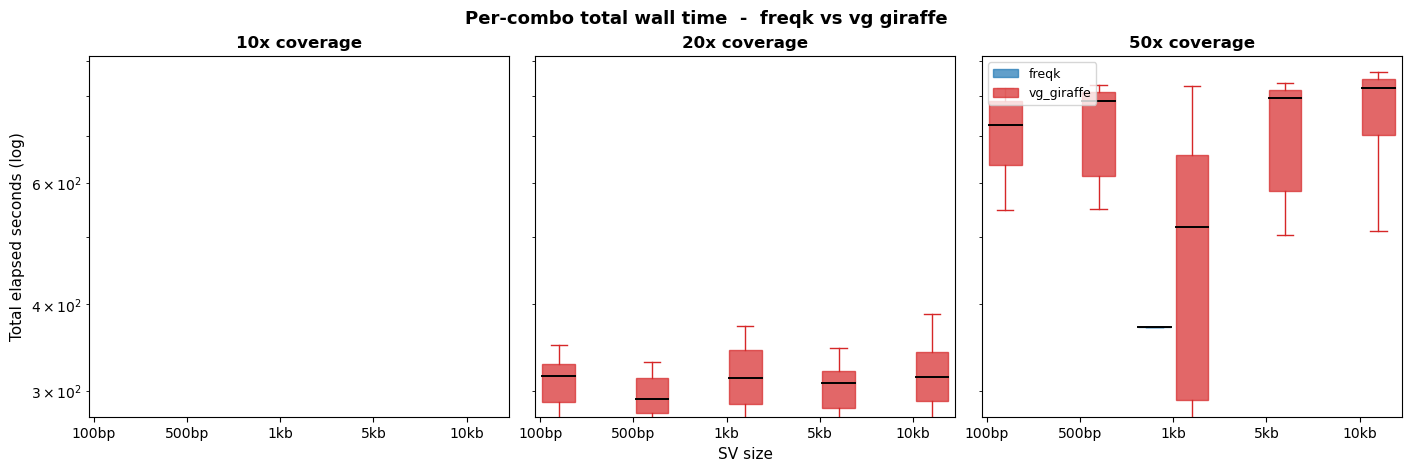


Median total seconds per (method, coverage, size):
size                 100bp  500bp    1kb    5kb   10kb
method     coverage                                   
freqk      10          NaN    NaN   96.5    NaN    NaN
           20          NaN    NaN  165.0    NaN    NaN
           50          NaN    NaN  371.0    NaN    NaN
vg_giraffe 10        198.0  202.5  200.0  202.0  180.0
           20        315.0  292.0  313.0  307.5  313.5
           50        728.0  788.0  518.0  795.0  821.0


In [13]:
total = (rt.groupby(['rep', 'coverage', 'size', 'freq_label', 'method'])['elapsed_s']
           .sum().reset_index(name='total_s'))

fig, axes = plt.subplots(1, len(COV_ORDER), figsize=(14, 4.6),
                         sharey=True, constrained_layout=True)
if len(COV_ORDER) == 1:
    axes = [axes]

box_positions = np.arange(len(SIZE_ORDER)) * 2.0
offsets = {'freqk': -0.4, 'vg_giraffe': 0.4}

for ax, cov in zip(axes, COV_ORDER):
    sub = total[total['coverage'] == cov]
    ns_per_size = []
    for mth in METHODS:
        for j, sz in enumerate(SIZE_ORDER):
            vals = sub[(sub['method'] == mth) & (sub['size'] == sz)]['total_s'].values
            if len(vals) == 0:
                continue
            bp = ax.boxplot([vals], positions=[box_positions[j] + offsets[mth]],
                            widths=0.7, patch_artist=True,
                            showfliers=False,
                            boxprops=dict(facecolor=METHOD_COLOR[mth], alpha=0.7,
                                          edgecolor=METHOD_COLOR[mth]),
                            medianprops=dict(color='black', linewidth=1.4),
                            whiskerprops=dict(color=METHOD_COLOR[mth]),
                            capprops=dict(color=METHOD_COLOR[mth]))
        ns_per_size.append(None)

    ax.set_xticks(box_positions)
    ax.set_xticklabels(SIZE_ORDER, fontsize=10)
    ax.set_title(f'{cov}x coverage', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    ax.set_yscale('log')

axes[0].set_ylabel('Total elapsed seconds (log)', fontsize=11)
axes[len(axes)//2].set_xlabel('SV size', fontsize=11)

handles = [mpatches.Patch(color=METHOD_COLOR[m], alpha=0.7, label=m) for m in METHODS]
axes[-1].legend(handles=handles, loc='upper left', fontsize=9, frameon=True)

fig.suptitle('Per-combo total wall time  -  freqk vs vg giraffe',
             fontsize=13, fontweight='bold')

plt.savefig(f'{PLOT_DIR}/freqk_vs_vg_runtime_total.png',
            bbox_inches='tight', dpi=200)
plt.show()

print()
print('Median total seconds per (method, coverage, size):')
med = (total.groupby(['method', 'coverage', 'size'])['total_s'].median()
            .unstack('size').reindex(columns=SIZE_ORDER))
print(med.round(1))


### Plot 9 — per-step breakdown for vg giraffe

Where vg's wall time goes (autoindex once-per-rep, giraffe mapping, pack, call). Cached steps (`cached=1`) are dropped so re-used indexes don't show as 0s. Means across all combos with non-cached timings.


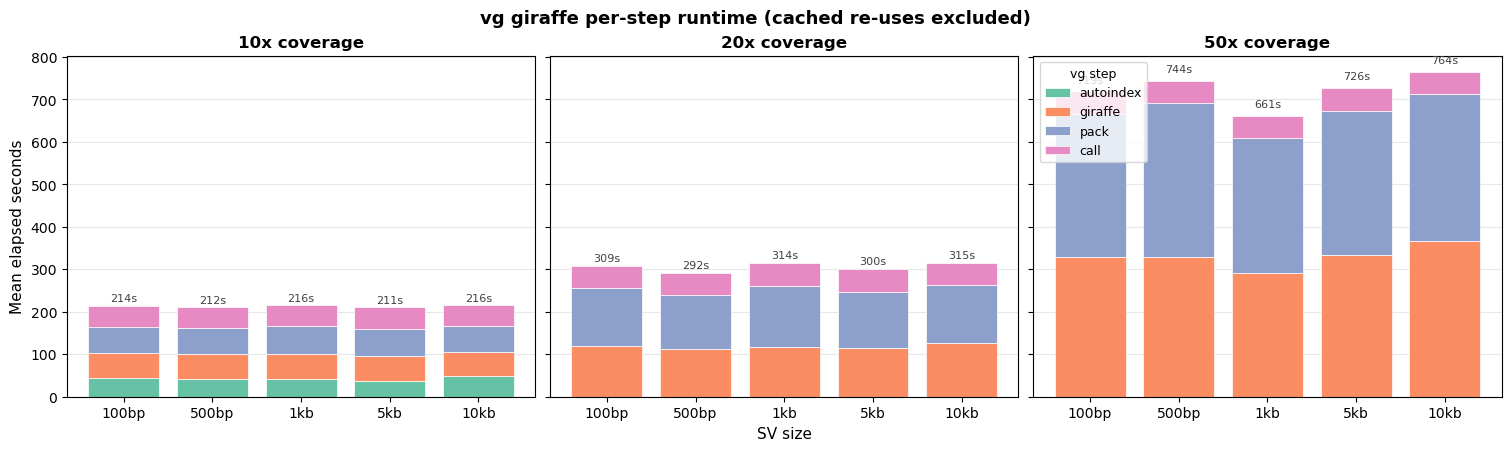


freqk per-step mean (s) - 4 combos:
step           index  combine_reads  var-dedup  ref-dedup  count  call
coverage size                                                         
10       1kb     0.0           15.0        0.0       29.0   52.5   0.0
20       1kb     0.0           34.0        0.0       27.0  104.0   0.0
50       1kb     0.0           82.0        0.0       28.0  261.0   0.0


In [14]:
VG_STEPS    = ['autoindex', 'giraffe', 'pack', 'call']
FREQK_STEPS = ['index', 'combine_reads', 'var-dedup', 'ref-dedup', 'count', 'call']

vg_rt = rt[(rt['method'] == 'vg_giraffe') & (rt['cached'] != 1)].copy()

mean_step = (vg_rt.groupby(['coverage', 'size', 'step'])['elapsed_s']
                  .mean().unstack('step')
                  .reindex(columns=VG_STEPS, fill_value=0))

fig, axes = plt.subplots(1, len(COV_ORDER), figsize=(15, 4.4),
                         sharey=True, constrained_layout=True)
if len(COV_ORDER) == 1:
    axes = [axes]

step_palette = sns.color_palette('Set2', len(VG_STEPS))
step_colors  = dict(zip(VG_STEPS, step_palette))

x = np.arange(len(SIZE_ORDER))
for ax, cov in zip(axes, COV_ORDER):
    if cov in mean_step.index:
        sub = mean_step.loc[cov].reindex(SIZE_ORDER, fill_value=0).fillna(0)
    else:
        sub = pd.DataFrame(0, index=SIZE_ORDER, columns=VG_STEPS)
    bottom = np.zeros(len(SIZE_ORDER))
    for step in VG_STEPS:
        vals = sub[step].values.astype(float)
        ax.bar(x, vals, bottom=bottom,
               color=step_colors[step], edgecolor='white', linewidth=0.5,
               label=step)
        bottom += vals

    top = float(np.nanmax(bottom)) if bottom.size else 0.0
    for i, total_s in enumerate(bottom):
        if not np.isfinite(total_s):
            continue
        ax.text(i, total_s + (top * 0.02 if top > 0 else 1),
                f'{int(round(total_s))}s',
                ha='center', va='bottom', fontsize=8, color='0.25')

    ax.set_xticks(x); ax.set_xticklabels(SIZE_ORDER, fontsize=10)
    ax.set_title(f'{cov}x coverage', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, zorder=0); ax.set_axisbelow(True)

axes[0].set_ylabel('Mean elapsed seconds', fontsize=11)
axes[len(axes)//2].set_xlabel('SV size', fontsize=11)
axes[-1].legend(title='vg step', loc='upper left',
                fontsize=9, title_fontsize=9, frameon=True)
fig.suptitle('vg giraffe per-step runtime (cached re-uses excluded)',
             fontsize=13, fontweight='bold')

plt.savefig(f'{PLOT_DIR}/freqk_vs_vg_runtime_vg_steps.png',
            bbox_inches='tight', dpi=200)
plt.show()

freqk_rt = rt[(rt['method'] == 'freqk') & (rt['cached'] != 1)].copy()
if len(freqk_rt):
    print(f'\nfreqk per-step mean (s) - {freqk_rt[["rep","coverage","size","freq_label"]].drop_duplicates().shape[0]} combos:')
    print(freqk_rt.groupby(['coverage', 'size', 'step'])['elapsed_s']
                  .mean().unstack('step')
                  .reindex(columns=FREQK_STEPS, fill_value=0)
                  .round(1))
else:
    print('\nNo freqk runtime TSVs on disk yet (instrumentation post-dates older combos).')
